# AI Programming Foundations 
**Name:** Ahmad  
**Dataset:** Titanic (Kaggle)  
**Description:** This notebook demonstrates a complete, reproducible data workflow: loading data, cleaning, exploratory analysis, visualization, and communicating findings in a clear structure.


## Dataset
Titanic (Kaggle) - https://www.kaggle.com/c/titanic/data

## What I Built
- `data_workflow.ipynb`
- `requirements.txt`
- `module_summary.pdf`

In [1]:
# Setup

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
pd.set_option("display.max_columns", None)

In [2]:
# Create folder to save plots 

PLOTS_DIR = "images"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [3]:
# Ingestion

def load_titanic_train() -> pd.DataFrame:
    """
    Load Titanic training dataset from common candidate locations.
    Returns a DataFrame.
    """
    candidate_paths = [
        "titanic_data/train.csv",
        "train.csv",
        "/mnt/data/train.csv",
    ]
    for path in candidate_paths:
        if os.path.exists(path):
            return pd.read_csv(path)
    raise FileNotFoundError(
        "Could not find train.csv. Place it in titanic_data/train.csv or next to the notebook."
    )

df = load_titanic_train()

print("Raw shape:", df.shape)
display(df.head())
print("\nRaw info:")
df.info()

print("\nTop missing columns (count):")
display(df.isna().sum().sort_values(ascending=False).head(15))

Raw shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Raw info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Top missing columns (count):


Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [4]:
# Cleaning Functions

def standardize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize column names: strip whitespace, lowercase, replace spaces with underscores.
    Returns a copy to keep the workflow reproducible and non-destructive.
    """
    out = df.copy()
    out.columns = out.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
    return out

def fill_missing_with_group_median(df: pd.DataFrame, target_col: str, group_col: str) -> pd.DataFrame:
    """
    Fill missing values in `target_col` using the median within each `group_col`.
    Falls back to the global median if a group median cannot be computed.
    Returns a copy.
    """
    out = df.copy()

    out[target_col] = pd.to_numeric(out[target_col], errors="coerce")

    global_median = out[target_col].median()
    group_median = out.groupby(group_col)[target_col].transform("median")
    out[target_col] = out[target_col].fillna(group_median).fillna(global_median)
    return out

def drop_rows_missing_small_critical_fields(df: pd.DataFrame, critical_cols: list) -> pd.DataFrame:
    """
    Drop rows missing values in critical columns when missingness is minimal.
    Returns a copy.
    """
    out = df.copy()
    existing = [c for c in critical_cols if c in out.columns]
    if not existing:
        return out
    return out.dropna(subset=existing)

In [5]:
# Apply cleaning pipeline

df_clean = standardize_column_names(df)

# Age: impute using median by passenger class 
if {"age", "pclass"}.issubset(df_clean.columns):
    df_clean = fill_missing_with_group_median(df_clean, "age", "pclass")

# Embarked: only a few missing rows
df_clean = drop_rows_missing_small_critical_fields(df_clean, ["embarked"])

print("\nAfter cleaning - missing values (top):")
display(df_clean.isna().sum().sort_values(ascending=False).head(15))
print("Clean shape:", df_clean.shape)

# Cabin: very high missingness
CABIN_MISSING_PCT = float(df_clean["cabin"].isna().mean() * 100) if "cabin" in df_clean.columns else 0.0
print(f"\nCabin missingness: {CABIN_MISSING_PCT:.2f}% (excluded from analysis/plots)")


After cleaning - missing values (top):


cabin          687
passengerid      0
survived         0
pclass           0
name             0
sex              0
age              0
sibsp            0
parch            0
ticket           0
fare             0
embarked         0
dtype: int64

Clean shape: (889, 12)

Cabin missingness: 77.28% (excluded from analysis/plots)


In [6]:
# EDA Function(s)

def eda_report(df: pd.DataFrame) -> None:
    """
    Compact EDA report:
    - shape
    - missing percentage (top)
    - numeric summary stats
    - survival group comparisons (sex, pclass, embarked) if present
    """
    print("Shape:", df.shape)

    print("\nMissing (% top 10):")
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    display(missing_pct.head(10))

    print("\nNumeric summary:")
    display(df.describe(include=[np.number]).T)

    if "survived" in df.columns:
        if "sex" in df.columns:
            print("\nSurvival rate by sex:")
            display(df.groupby("sex")["survived"].mean().sort_values(ascending=False))
        if "pclass" in df.columns:
            print("\nSurvival rate by pclass:")
            display(df.groupby("pclass")["survived"].mean().sort_values(ascending=False))
        if "embarked" in df.columns:
            print("\nSurvival rate by embarked:")
            display(df.groupby("embarked")["survived"].mean().sort_values(ascending=False))

eda_report(df_clean)

Shape: (889, 12)

Missing (% top 10):


cabin          77.27784
passengerid     0.00000
survived        0.00000
pclass          0.00000
name            0.00000
sex             0.00000
age             0.00000
sibsp           0.00000
parch           0.00000
ticket          0.00000
dtype: float64


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
passengerid,889.0,446.000000,256.998173,1.00,224.0000,446.0000,668.0,891.0000
survived,889.0,0.382452,0.486260,0.00,0.0000,0.0000,1.0,1.0000
pclass,889.0,2.311586,0.834700,1.00,2.0000,3.0000,3.0,3.0000
age,889.0,29.019314,13.209814,0.42,22.0000,26.0000,36.5,80.0000
sibsp,889.0,0.524184,1.103705,0.00,0.0000,0.0000,1.0,8.0000
parch,889.0,0.382452,0.806761,0.00,0.0000,0.0000,0.0,6.0000
fare,889.0,32.096681,49.697504,0.00,7.8958,14.4542,31.0,512.3292



Survival rate by sex:


sex
female    0.740385
male      0.188908
Name: survived, dtype: float64


Survival rate by pclass:


pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64


Survival rate by embarked:


embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64

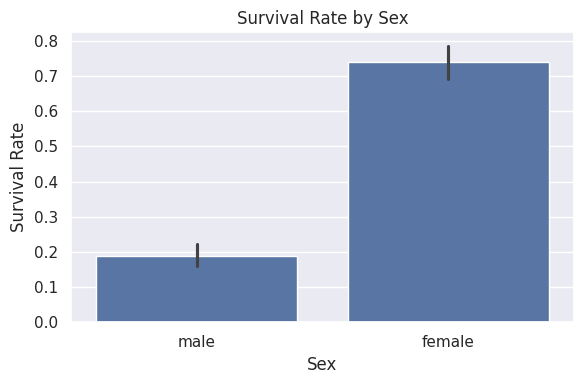

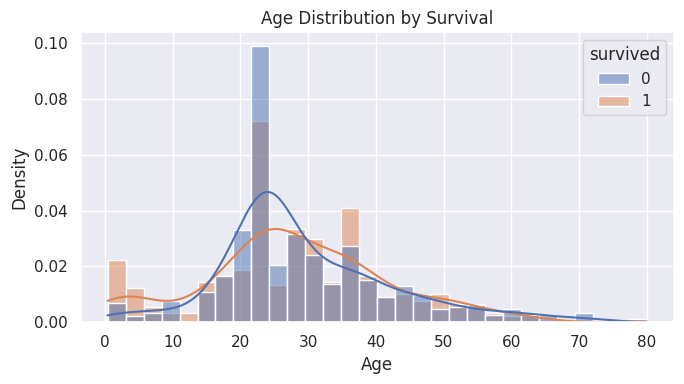

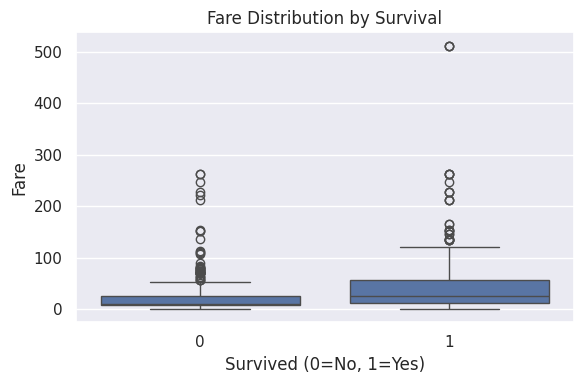

In [7]:
# Visualizations 

# 1: Survival rate by Sex
if {"survived", "sex"}.issubset(df_clean.columns):
    plt.figure(figsize=(6, 4))
    sns.barplot(data=df_clean, x="sex", y="survived", errorbar=("ci", 95))
    plt.title("Survival Rate by Sex")
    plt.xlabel("Sex")
    plt.ylabel("Survival Rate")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "viz_survival_by_sex.png"), dpi=150)
    plt.show()

# 2: Age distribution by Survival
if {"age", "survived"}.issubset(df_clean.columns):
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df_clean,
        x="age",
        hue="survived",
        bins=30,
        kde=True,
        stat="density",
        common_norm=False
    )
    plt.title("Age Distribution by Survival")
    plt.xlabel("Age")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "viz_age_by_survival.png"), dpi=150)
    plt.show()
    
# 3: Fare distribution by Survival (boxplot)
if {"fare", "survived"}.issubset(df_clean.columns):
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_clean, x="survived", y="fare")
    plt.title("Fare Distribution by Survival")
    plt.xlabel("Survived (0=No, 1=Yes)")
    plt.ylabel("Fare")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "viz_fare_by_survival.png"), dpi=150)
    plt.show()

In [8]:
summary_text = """
Summary
- Loaded Titanic training data and standardized column names for consistent, reproducible analysis.
- Imputed missing Age values using the median Age within each passenger class (Pclass).
- Dropped the small number of rows missing Embarked; Cabin has ~77% missingness and is excluded from analysis/plots.
- Key findings: survival differs strongly by Sex and Pclass; higher fares are associated with higher survival.
- Limitations: observational historical data; imputation choices and heavy missingness (Cabin) can influence results.
"""
print(summary_text)


Summary
- Loaded Titanic training data and standardized column names for consistent, reproducible analysis.
- Imputed missing Age values using the median Age within each passenger class (Pclass).
- Dropped the small number of rows missing Embarked; Cabin has ~77% missingness and is excluded from analysis/plots.
- Key findings: survival differs strongly by Sex and Pclass; higher fares are associated with higher survival.
- Limitations: observational historical data; imputation choices and heavy missingness (Cabin) can influence results.



In [9]:
# Save cleaned dataset

df_clean.to_csv("train_clean.csv", index=False)
print("\nSaved cleaned dataset: train_clean.csv")
print(f"Saved plots in: {PLOTS_DIR}/")


Saved cleaned dataset: train_clean.csv
Saved plots in: images/


# Workflow Summary

## Overview
This project implements a reproducible data workflow using the Titanic dataset from Kaggle. The workflow demonstrates data ingestion, cleaning, exploratory analysis, visualization, and interpretation using Python.

## Dataset Description
The Titanic dataset contains passenger-level information including demographics, ticket details, and survival outcomes. The training dataset includes 891 rows and 12 columns, with key variables such as Survived, Sex, Age, Pclass, and Fare. Several variables contain missing values, particularly Age and Cabin.

## Workflow Description
The workflow follows a structured and reproducible process:
- Data ingestion using Pandas
- Data cleaning and missing value handling
- Exploratory data analysis
- Visualization of key patterns
- Summary interpretation

## Key Decisions and Assumptions
Missing age values were imputed using the median age within each passenger class to preserve class-based structure. The Cabin feature was excluded due to high missingness. These decisions align with reproducible data science best practices.

## Results and Interpretation
Survival rates differ significantly by sex and passenger class. Female passengers and those in higher classes had higher survival rates. Higher fares were also associated with increased survival, reflecting socioeconomic effects.

## Responsible Practice (Bias and Data Quality)
Imputation and data removal may introduce bias if missingness is not random. Group-based imputation may reinforce class-related patterns. All cleaning steps are documented for transparency.

## Reproducibility
The analysis is fully reproducible using the provided notebook, requirements.txt file, and Git version control with multiple commits and branches.

## References
Rule, A. et al. (2019). Reproducible Data Science with Python. *PLOS Computational Biology*.

VanderPlas, J. (2016). *Python Data Science Handbook*. O’Reilly Media.